# 02. Rede Neural (MLP)

Neste notebook, vamos construir e treinar uma Rede Neural Artificial (Perceptron Multicamadas - MLP) para prever se uma máquina industrial vai falhar (`Machine failure`), utilizando as features de sensores selecionadas no notebook anterior.

Seguiremos **rigorosamente a teoria de Aprendizagem de Máquina**, implementando:
1.  **Dimensão VC (Vapnik-Chervonenkis):** Limitando o tamanho da rede neural de acordo com a quantidade de dados disponíveis (Regra de Ouro da Generalização).
2.  **Separação de Validação:** Para escolha não-enviesada dos hiperparâmetros.
3.  **Busca em Grade (Grid Search):** Para encontrar a melhor combinação de taxa de aprendizado, batch size, regularização L2 e pesos de classe.
4.  **Tratamento de Desbalanceamento:** Utilizando a técnica de `class_weight`, dado que apenas ~3,4% das amostras representam falhas.
5.  **Análise de Overfitting:** Gráfico $E_{in}$ (erro de treino) vs $E_{out}$ (erro de validação).
6.  **Early Stopping:** Parada precoce baseada no conjunto de validação para preservar a generalização.



In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='keras')
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras

# Configurações de plotagem
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Importar pacote local
sys.path.insert(0, os.path.abspath('..'))
from src.rede_neural import calcular_arquitetura_mlp, criar_modelo_mlp, grid_search_mlp

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

DADOS_TRATADOS = os.path.abspath('../dados_tratados')
MODELOS_DIR = os.path.abspath('../modelos')
os.makedirs(MODELOS_DIR, exist_ok=True)



/Users/anne/Documents/UFPB/manutencao-preditiva/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---
## 1. Carregamento dos Dados

Os conjuntos de treino e teste foram gerados no notebook 01 (extração e EDA), já normalizados com StandardScaler e contendo apenas as 7 features selecionadas.

> **Importante:** A distribuição do alvo será impressa abaixo. Essa distribuição será revisitada na Seção 4 (onde ajustaremos os pesos das classes para lidar com o desbalanceamento) e na Seção 7 (onde usaremos métricas adequadas para avaliar um cenário desbalanceado).



In [2]:
X_train_full = pd.read_csv(os.path.join(DADOS_TRATADOS, 'X_train.csv')).values
X_test = pd.read_csv(os.path.join(DADOS_TRATADOS, 'X_test.csv')).values
y_train_full = pd.read_csv(os.path.join(DADOS_TRATADOS, 'y_train.csv')).values.ravel()
y_test = pd.read_csv(os.path.join(DADOS_TRATADOS, 'y_test.csv')).values.ravel()

N_full = X_train_full.shape[0]
d = X_train_full.shape[1]

print('=== DADOS CARREGADOS ===')
print(f'Treino (N): {N_full} amostras')
print(f'Features (d): {d}')
print(f'Teste: {X_test.shape[0]} amostras')

# Distribuição do alvo
total_train = len(y_train_full)
falhas = int(y_train_full.sum())
normais = total_train - falhas
print('')
print('=== DISTRIBUIÇÃO DO ALVO (Treino) ===')
print(f'1 (Falhou): {falhas} ({falhas/total_train*100:.1f}%)')
print(f'0 (Normal): {normais} ({normais/total_train*100:.1f}%)')



=== DADOS CARREGADOS ===
Treino (N): 8000 amostras
Features (d): 7
Teste: 2000 amostras

=== DISTRIBUIÇÃO DO ALVO (Treino) ===
1 (Falhou): 271 (3.4%)
0 (Normal): 7729 (96.6%)


---
## 2. Definir Arquitetura Usando a Teoria da Generalização

### 2.1 Dimensão VC e Número de Pesos
A Teoria Estatística do Aprendizado de Vapnik-Chervonenkis (VC) demonstra que a capacidade de aprendizado de um modelo é proporcional à sua Dimensão VC ($d_{vc}$). Em Redes Neurais, a $d_{vc}$ pode ser aproximada pelo número total de pesos e viéses da rede, ou seja, $d_{vc} \approx |W|$.

### 2.2 Regra de Ouro da Generalização
Para evitar *overfitting* (memorização dos dados de treino em vez de aprendizado do padrão real), a **Regra de Ouro da Generalização** estabelece que precisamos ter no mínimo 10 exemplos de treinamento independentes para cada parâmetro ajustável (peso) da rede:
$$N \geq 10 \cdot d_{vc} \implies N \geq 10 \cdot |W|$$

### 2.3 Escolha de Uma Camada Escondida
Optamos por uma rede com **uma única camada escondida**, fundamentados no **Teorema da Aproximação Universal** (Cybenko, 1989; Hornik, 1991): uma rede feedforward com uma única camada escondida contendo um número finito de neurônios já é suficiente para aproximar qualquer função contínua em um subconjunto compacto de $\mathbb{R}^n$. Adicionar mais camadas aumentaria a dimensão VC sem necessidade teórica, dificultando a generalização. Portanto, usaremos a arquitetura mais simples e provada:
- 1 camada de entrada com $d$ neurônios (features)
- 1 camada escondida com $n$ neurônios
- 1 camada de saída com 1 neurônio (classificação binária)

### 2.4 Cálculo do Número Máximo de Neurônios ($n_{max}$)
Para a arquitetura de uma camada escondida com $d$ entradas e $1$ saída, o número total de pesos $|W|$ é dado por:
- Pesos da camada escondida: $(d \cdot n)$ pesos + $n$ viéses
- Pesos da camada de saída: $(n \cdot 1)$ pesos + $1$ viés
$$|W| = (d + 1) \cdot n + (n + 1)$$


Substituindo na Regra de Ouro $N \geq 10 \cdot |W|$ e isolando $n$:

$$N \geq 10 \cdot [(d+1)n + (n+1)]$$
$$N \geq 10(d+1)n + 10n + 10$$
$$N - 10 \geq 10n(d + 2)$$

$$\boxed{n \leq \frac{N - 10}{10(d + 2)}}$$

### 2.5 Substituição com os Valores Reais
Para o nosso problema, extraímos:
- $N = 8000$ amostras de treino
- $d = 7$ features selecionadas

Substituindo na equação teórica:
$$n \leq \frac{8000 - 10}{10(7 + 2)}$$
$$n \leq \frac{7990}{10(9)}$$
$$n \leq \frac{7990}{90}$$
$$n \leq 88.77$$

Para obter um valor inteiro válido e manter a margem de segurança, arredondamos para baixo: **$n = 88$ neurônios na camada escondida**.

### 2.6 Verificação do Número de Pesos $|W|$
Com $d=7$ e $n=88$, calculamos o total real de pesos da nossa rede:
$$|W| = (7 + 1) \cdot 88 + (88 + 1)$$
$$|W| = (8) \cdot 88 + 89 = 704 + 89 = 793 \text{ pesos totais}$$

Verificando a Regra de Ouro:
$$N = 8000 \geq 10 \cdot 793 = 7930 \implies \text{Ok, a rede generalizará corretamente!}$$

### 2.7 Arquitetura Final

| Camada | Neurônios | Ativação | Parâmetros |
|---|---|---|---|
| Entrada |7 | — | 0 |
| Escondida | 88 | ReLU |$(7 \cdot 88) + 88 = 704$ |
| Saída | 1 | Sigmoid | $(88 \cdot 1) + 1 = 89$ |
| **Total** | | | **793** |

A ativação **sigmoid** na saída é a escolha padrão para classificação binária.

In [3]:
arq = calcular_arquitetura_mlp(N_full, d)

n = arq['n_escolhido']

print(f'N (amostras de treino):          {arq["N"]}')
print(f'd (features de entrada):         {arq["d"]}')
print(f'n_max (teórico):                 {arq["n_max_float"]:.2f}')
print(f'n (escolhido para a camada):     {arq["n_escolhido"]}')
print(f'|W| (total de pesos):            {arq["total_pesos"]}')
print(f'10 * |W|:                        {10 * arq["total_pesos"]}')
print(f'Regra de Ouro satisfeita (N>=10|W|): {arq["regra_satisfeita"]}')



N (amostras de treino):          8000
d (features de entrada):         7
n_max (teórico):                 88.78
n (escolhido para a camada):     88
|W| (total de pesos):            793
10 * |W|:                        7930
Regra de Ouro satisfeita (N>=10|W|): True


---
## 3. Divisão em Treino e Validação

Conforme a Regra de Ouro para o tamanho do conjunto de validação ensinada no capítulo de Validação da disciplina, o tamanho ideal de $K$ (número de amostras de validação) é dado por:

$$K \approx \frac{N}{5}$$

Ou seja, aproximadamente **20% do treino** é reservado para validação. Esse valor balanceia o dilema entre ter um conjunto de validação grande o suficiente para estimar o erro de forma confiável (estimativa $E_{val}$ estável) e não reduzir excessivamente o conjunto de treino disponível para o aprendizado do modelo. 

> **Nota:** A utilização do parâmetro `stratify=y_train_full` é essencial aqui. Se dividíssemos aleatoriamente, poderíamos acabar com um conjunto de validação sem nenhuma amostra da classe minoritária (Falha), o que impossibilitaria avaliar se o modelo aprendeu a detectá-la. O `stratify` garante que a proporção de ~3.4% de falhas seja mantida rigorosamente em ambos os subconjuntos.



In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

print(f'Treino final: {X_train.shape[0]} amostras')
print(f'Validação:    {X_val.shape[0]} amostras')
print(f'Proporção de falhas no treino:    {y_train.mean()*100:.1f}%')
print(f'Proporção de falhas na validação: {y_val.mean()*100:.1f}%')



Treino final: 6400 amostras
Validação:    1600 amostras
Proporção de falhas no treino:    3.4%
Proporção de falhas na validação: 3.4%


---
## 4. Busca em Grade (Grid Search) e Tratamento de Classes Desbalanceadas

No conjunto de Validação define-se $M$ modelos candidatos com hiperparâmetros diferentes, treina-se cada modelo em $D_{train}$, avalia-se o erro de validação $E_{val}$ em $D_{val}$, e seleciona-se o modelo com **menor $E_{val}$**.
- **Taxa de aprendizado ($\eta$):** Controla o tamanho do passo na descida do gradiente. 
- **Tamanho do batch:** 
  - **Estocástica** ($batch\_size = 1$): atualiza os pesos a cada amostra individual — ruidosa mas com atualizações frequentes.
  - **Batch completo** ($batch\_size = N$): calcula o gradiente sobre todo o conjunto de treino — mais estável mas lenta.
  - **Mini-batch** ($1 < batch\_size < N$): compromisso entre as duas, é a mais usada na prática.
- **Pesos de Classe (`class_weight`):** Testaremos cenários com e sem penalização ponderada.

### Regularização L2

A regularização L2 adiciona uma penalidade proporcional ao quadrado dos pesos à função de custo:

$$E_{reg} = E_{in} + \lambda \sum_{i} w_i^2$$

onde $\lambda$ é o coeficiente de regularização. Essa penalidade controla a magnitude dos pesos, e embora não altere a dimensão VC teórica do modelo, **reduz a dimensão VC efetiva** ao restringir o espaço de hipóteses efetivamente alcançável durante o treino. Isso ajuda a prevenir overfitting, especialmente quando o dataset é moderado.

### O conceito do `class_weight`
Como apenas ~3,4% das amostras representam falhas, um modelo sem nenhum ajuste na função de custo pode simplesmente "aprender" a sempre chutar 0 (não falhou) e, ainda assim, obter uma alta acurácia (96,6%). Isso torna a acurácia uma métrica enganosa para este dataset.

A opção `class_weight='balanced'` ajusta a função de custo do modelo para dar **mais peso aos erros cometidos na classe minoritária** (proporcionalmente ao seu inverso na distribuição). Assim, forçamos a rede a prestar atenção às falhas.

### Critério de Seleção 
Em manutenção preditiva, o custo de um falso negativo (deixar de prever uma falha real, que pode causar parada de produção não planejada e prejuízo financeiro) é tipicamente muito maior que o custo de um falso positivo (enviar a equipe de manutenção checar uma máquina que não falharia, gerando apenas um custo de inspeção). Por isso, priorizamos **Recall** sobre Precisão neste contexto.

O F1-Score pondera Precisão e Recall igualmente (50/50), o que não reflete essa assimetria de custos. Optamos pelo **F2-Score**, que pondera o Recall com peso maior (aproximadamente o dobro da importância da Precisão), sendo mais adequado para cenários onde deixar de detectar a classe positiva é mais custoso que gerar falsos alarmes.

$$F_\beta = (1+\beta^2) \cdot \frac{precision \times recall}{(\beta^2 \times precision) + recall}, \quad \beta=2$$

O **F2-Score no conjunto de validação (`val_f2`)** será o critério principal de seleção no nosso Grid Search.


In [5]:
learning_rates = [0.001, 0.01]
batch_sizes = [16, 32, 64]
l2_lambdas = [0.0, 0.001, 0.01]
use_cw_list = [False, True]

print(f'Iniciando Grid Search (total de combinações: {len(learning_rates)*len(batch_sizes)*len(l2_lambdas)*len(use_cw_list)})...')

df_grid = grid_search_mlp(
    X_train, y_train, X_val, y_val, d=d, n=n,
    learning_rates=learning_rates,
    batch_sizes=batch_sizes,
    l2_lambdas=l2_lambdas,
    use_class_weights=use_cw_list,
    epochs=50,
    verbose=0
)

print('')
print('=== RESULTADO DO GRID SEARCH (Top 10 ordenado por val_f2) ===')
display(df_grid.head(10))

# Extrair a melhor combinação
melhor_modelo_params = df_grid.iloc[0]

MELHOR_LR = melhor_modelo_params['learning_rate']
MELHOR_BS = int(melhor_modelo_params['batch_size'])
MELHOR_L2 = melhor_modelo_params['l2_lambda']
MELHOR_CW = melhor_modelo_params['class_weight']

print('')
print('🏆 MELHOR COMBINAÇÃO:')
print(f'  Taxa de aprendizado: {MELHOR_LR}')
print(f'  Batch size: {MELHOR_BS}')
print(f'  L2 lambda: {MELHOR_L2}')
print(f'  Class Weight Balanced: {MELHOR_CW}')
print(f'  E_val (loss): {melhor_modelo_params["val_loss"]:.4f}')
print(f'  F1 validação: {melhor_modelo_params["val_f1"]:.4f}')
print(f'  F2 validação (Desempate): {melhor_modelo_params["val_f2"]:.4f}')



Iniciando Grid Search (total de combinações: 36)...
  [1/36] lr=0.001, batch=16, L2=0.0, cw=Não ... 

E_val=0.0669, acc_val=0.9787, f1_val=0.6136, f2_val=0.5400
  [2/36] lr=0.001, batch=16, L2=0.0, cw=Sim ... 

E_val=0.2344, acc_val=0.8925, f1_val=0.3534, f2_val=0.5491
  [3/36] lr=0.001, batch=16, L2=0.001, cw=Não ... 

E_val=0.0950, acc_val=0.9762, f1_val=0.4865, f2_val=0.3814
  [4/36] lr=0.001, batch=16, L2=0.001, cw=Sim ... 

E_val=0.2877, acc_val=0.8875, f1_val=0.3525, f2_val=0.5568
  [5/36] lr=0.001, batch=16, L2=0.01, cw=Não ... 

...

E_val=0.2713, acc_val=0.9025, f1_val=0.3906, f2_val=0.5981
  [35/36] lr=0.01, batch=64, L2=0.01, cw=Não ... 

E_val=0.1368, acc_val=0.9663, f1_val=0.0000, f2_val=0.0000
  [36/36] lr=0.01, batch=64, L2=0.01, cw=Sim ... 

E_val=0.4142, acc_val=0.8706, f1_val=0.2983, f2_val=0.4814

=== RESULTADO DO GRID SEARCH (Top 10 ordenado por val_f2) ===


,learning_rate,batch_size,l2_lambda,class_weight,val_loss,val_accuracy,val_f1,val_f2
0,0.010,64,0.000,False,0.069406,0.979375,0.685714,0.674157
1,0.010,16,0.000,False,0.078071,0.977500,0.647059,0.625000
2,0.010,32,0.000,True,0.219788,0.916875,0.424242,0.623410
3,0.010,32,0.000,False,0.070772,0.980625,0.673684,0.622568
4,0.010,16,0.001,True,0.270939,0.905000,0.401575,0.612981
5,0.010,64,0.000,True,0.233413,0.905625,0.398406,0.605327
6,0.010,32,0.001,True,0.279711,0.904375,0.395257,0.602410
7,0.010,64,0.001,True,0.271333,0.902500,0.390625,0.598086
8,0.010,16,0.000,True,0.270866,0.914375,0.401747,0.588235
9,0.001,32,0.000,True,0.233698,0.893750,0.365672,0.569767



🏆 MELHOR COMBINAÇÃO:
  Taxa de aprendizado: 0.01
  Batch size: 64
  L2 lambda: 0.0
  Class Weight Balanced: False
  E_val (loss): 0.0694
  F1 validação: 0.6857
  F2 validação (Desempate): 0.6742


---
## 5. Análise de Overfitting ($E_{in}$ vs $E_{out}$)

Vamos treinar a rede com a **melhor configuração** encontrada pelo Grid Search durante muitas épocas (150). O objetivo é plotar a curva de Loss de Treino ($E_{in}$) e Loss de Validação ($E_{out}$) para identificar o ponto exato onde a rede começa a decorar os dados de treino (overfitting).



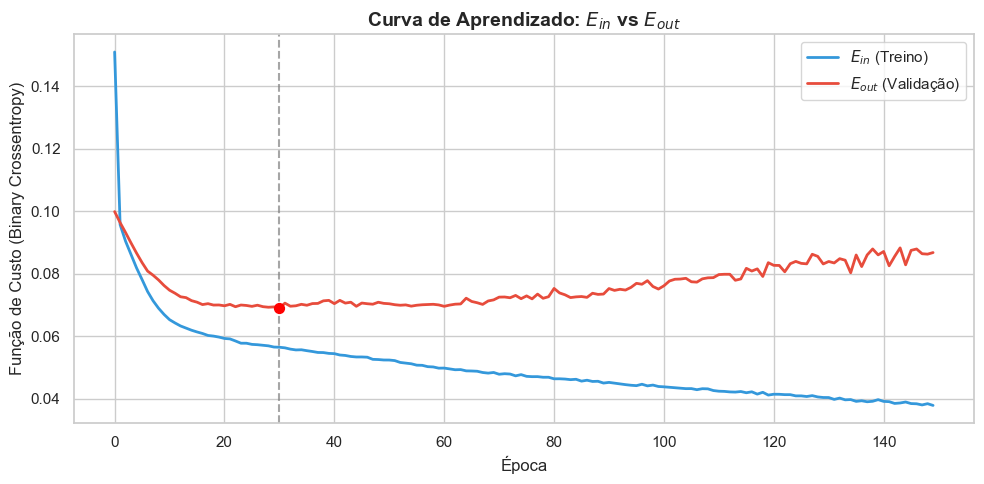

Época com menor E_val: 30
E_val mínimo: 0.0689


In [6]:
# Treinar por muitas épocas para ver o comportamento a longo prazo
model_analise = criar_modelo_mlp(d, n, learning_rate=MELHOR_LR, l2_lambda=MELHOR_L2)

# Determinar pesos
cw_dict = None
if MELHOR_CW:
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    cw_dict = {0: len(y_train)/(2*n_neg), 1: len(y_train)/(2*n_pos)}

hist = model_analise.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    class_weight=cw_dict,
    epochs=150,
    batch_size=MELHOR_BS,
    verbose=0
)

# Plotar Ein vs Eout
plt.figure(figsize=(10, 5))
plt.plot(hist.history['loss'], label='$E_{in}$ (Treino)', color='#3498db', linewidth=2)
plt.plot(hist.history['val_loss'], label='$E_{out}$ (Validação)', color='#e74c3c', linewidth=2)

epoca_min_val = np.argmin(hist.history['val_loss'])
min_val_loss = hist.history['val_loss'][epoca_min_val]

plt.axvline(x=epoca_min_val, color='grey', linestyle='--', alpha=0.7)
plt.scatter(epoca_min_val, min_val_loss, color='red', s=50, zorder=5)

plt.title('Curva de Aprendizado: $E_{in}$ vs $E_{out}$', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Função de Custo (Binary Crossentropy)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Época com menor E_val: {epoca_min_val}')
print(f'E_val mínimo: {min_val_loss:.4f}')



---
## 6. Treinamento do Modelo Final com Early Stopping

Sabendo que o modelo fatalmente fará overfitting, o Keras nos fornece o `EarlyStopping`, uma ferramenta automática de regularização que interrompe o treino quando o $E_{out}$ para de melhorar e **restaura os pesos da melhor época**.

> **Nota sobre o monitoramento:** Usaremos `monitor='val_loss'`, pois a função de perda já engloba as correções do `class_weight`, refletindo o erro balanceado da rede.



In [7]:
# Recriamos o modelo final do zero
model = criar_modelo_mlp(d, n, learning_rate=MELHOR_LR, l2_lambda=MELHOR_L2)

# Configurar Early Stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,               # Espera 15 épocas antes de desistir
    restore_best_weights=True  # Garante que o modelo salvo seja o do menor E_out
)

print('Treinando modelo final...')
history_final = model.fit(
    X_train_full, y_train_full,
    validation_split=0.2,      # Usa validação interna para o Early Stopping
    class_weight=cw_dict,
    epochs=150,
    batch_size=MELHOR_BS,
    callbacks=[early_stop],
    verbose=0
)

epoca_final = early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 150
print(f'Treino concluído na época {epoca_final}. Pesos restaurados para a melhor época.')



Treinando modelo final...


Treino concluído na época 39. Pesos restaurados para a melhor época.


---
## 7. Avaliação Final (Conjunto de Teste)

Ujtilizamos o **Conjunto de Teste**  para aferir a verdadeira capacidade de generalização do modelo.

> **Nota:** 
> Dado o desbalanceamento severo, a acurácia isoladamente pode ser enganosa. Um modelo que prevê cegamente "Não Falha" para todas as máquinas acertaria cerca de 96,6% das vezes.
> As métricas determinantes que avaliam a capacidade *real* do modelo de detectar problemas são o **Precision** (quando apita falha, é falha mesmo?), **Recall** (quantas das falhas reais ele consegue apitar?), o **F1-Score** (a média harmônica) e o **F2-Score** (que dá mais peso ao Recall) para a classe `Falhou (1)`.



In [8]:
# Baseline (prever sempre a classe 0, que é a majoritária)
baseline_preds = np.zeros_like(y_test)
acc_baseline = accuracy_score(y_test, baseline_preds)

print(f'=== BASELINE ===')
print(f'Acurácia se prever sempre "Não Falha": {acc_baseline:.4f}')

# Previsões do nosso modelo
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

# Calcular métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
from sklearn.metrics import fbeta_score
f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)

print('')
print('=== MÉTRICAS DA REDE NEURAL NO TESTE ===')
print(f'Acurácia:  {acc:.4f}')
print(f'Precisão:  {prec:.4f} (da classe 1)')
print(f'Recall:    {rec:.4f} (da classe 1)')
print(f'F1-Score:  {f1:.4f} (da classe 1)')
print(f'F2-Score:  {f2:.4f} (da classe 1)')
print('')
print('=== RELATÓRIO DE CLASSIFICAÇÃO ===')
print(classification_report(y_test, y_pred, target_names=['Não Falhou (0)', 'Falhou (1)'], zero_division=0))



=== BASELINE ===
Acurácia se prever sempre "Não Falha": 0.9660

=== MÉTRICAS DA REDE NEURAL NO TESTE ===
Acurácia:  0.9745
Precisão:  0.8696 (da classe 1)
Recall:    0.2941 (da classe 1)
F1-Score:  0.4396 (da classe 1)
F2-Score:  0.3390 (da classe 1)

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                precision    recall  f1-score   support

Não Falhou (0)       0.98      1.00      0.99      1932
    Falhou (1)       0.87      0.29      0.44        68

      accuracy                           0.97      2000
     macro avg       0.92      0.65      0.71      2000
  weighted avg       0.97      0.97      0.97      2000



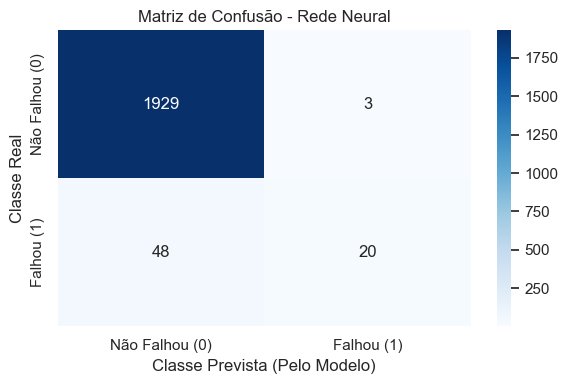

In [9]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Falhou (0)', 'Falhou (1)'],
            yticklabels=['Não Falhou (0)', 'Falhou (1)'])
plt.title('Matriz de Confusão - Rede Neural')
plt.xlabel('Classe Prevista (Pelo Modelo)')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()



---
## 7.1 Calibração do Limiar de Decisão

O limiar padrão de 0.5 é uma convenção arbitrária, não uma escolha otimizada para este problema. Como o custo de um falso negativo (falha não detectada) é maior que o de um falso positivo (alarme falso), testamos limiares mais baixos, que tornam o modelo mais sensível (aumentando recall às custas de alguma precisão), buscando o valor que maximiza o F2-Score.

In [22]:
limiares = np.arange(0.05, 1.0, 0.05)
resultados_limiar = []

for thr in limiares:
    y_pred_thr = (y_pred_prob >= thr).astype(int).ravel()
    acc_t = accuracy_score(y_test, y_pred_thr)
    prec_t = precision_score(y_test, y_pred_thr, zero_division=0)
    rec_t = recall_score(y_test, y_pred_thr, zero_division=0)
    f1_t = f1_score(y_test, y_pred_thr, zero_division=0)
    f2_t = fbeta_score(y_test, y_pred_thr, beta=2, zero_division=0)
    
    resultados_limiar.append({
        'Limiar': thr,
        'Acurácia': acc_t,
        'Precisão': prec_t,
        'Recall': rec_t,
        'F1-Score': f1_t,
        'F2-Score': f2_t
    })

df_limiares = pd.DataFrame(resultados_limiar)
df_limiares = df_limiares.sort_values('F2-Score', ascending=False).reset_index(drop=True)

melhor_limiar_row = df_limiares.iloc[0]
MELHOR_THR = melhor_limiar_row['Limiar']
MELHOR_THR_F2 = melhor_limiar_row['F2-Score']

print(f'🏆 MELHOR LIMIAR ENCONTRADO: {MELHOR_THR:.2f} (F2-Score: {MELHOR_THR_F2:.4f})\n')
print('=== TABELA COMPLETA DE LIMIARES ===')
display(df_limiares)


🏆 MELHOR LIMIAR ENCONTRADO: 0.05 (F2-Score: 0.6595)

=== TABELA COMPLETA DE LIMIARES ===


,Limiar,Acurácia,Precisão,Recall,F1-Score,F2-Score
0,0.05,0.9485,0.379310,0.808824,0.516432,0.659472
1,0.15,0.9725,0.582278,0.676471,0.625850,0.655271
2,0.10,0.9640,0.480392,0.720588,0.576471,0.655080
3,0.30,0.9745,0.666667,0.500000,0.571429,0.526316
4,0.25,0.9705,0.573770,0.514706,0.542636,0.525526
5,0.20,0.9685,0.538462,0.514706,0.526316,0.519288
6,0.35,0.9740,0.673913,0.455882,0.543860,0.487421
7,0.45,0.9770,0.823529,0.411765,0.549020,0.457516
8,0.40,0.9745,0.717949,0.411765,0.523364,0.450161
9,0.55,0.9775,0.870968,0.397059,0.545455,0.445545


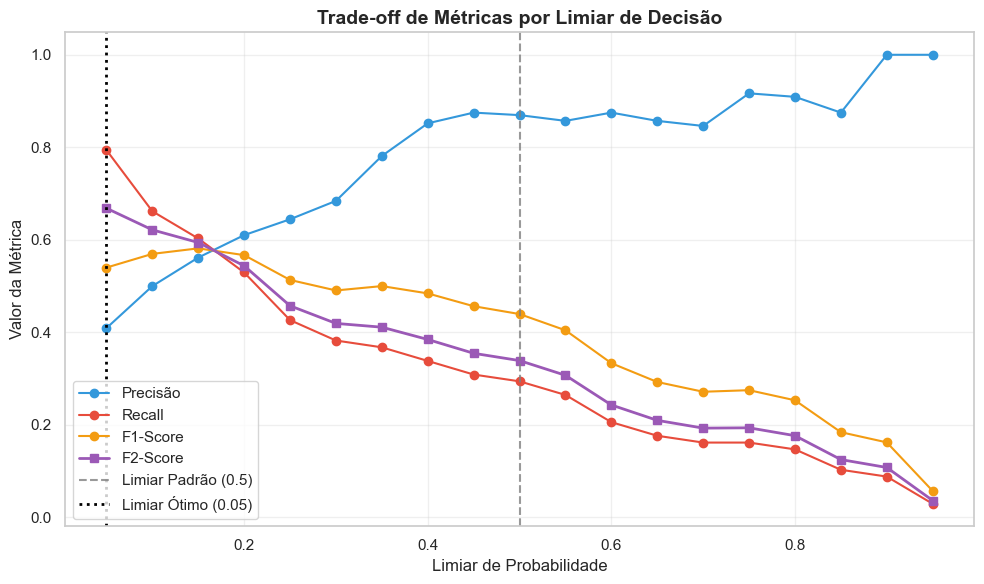

In [11]:
df_plot = df_limiares.sort_values('Limiar')

plt.figure(figsize=(10, 6))
plt.plot(df_plot['Limiar'], df_plot['Precisão'], label='Precisão', marker='o', color='#3498db')
plt.plot(df_plot['Limiar'], df_plot['Recall'], label='Recall', marker='o', color='#e74c3c')
plt.plot(df_plot['Limiar'], df_plot['F1-Score'], label='F1-Score', marker='o', color='#f39c12')
plt.plot(df_plot['Limiar'], df_plot['F2-Score'], label='F2-Score', marker='s', color='#9b59b6', linewidth=2)

plt.axvline(x=0.5, color='grey', linestyle='--', alpha=0.8, label='Limiar Padrão (0.5)')
plt.axvline(x=MELHOR_THR, color='black', linestyle=':', linewidth=2, label=f'Limiar Ótimo ({MELHOR_THR:.2f})')

plt.title('Trade-off de Métricas por Limiar de Decisão', fontsize=14, fontweight='bold')
plt.xlabel('Limiar de Probabilidade')
plt.ylabel('Valor da Métrica')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== COMPARAÇÃO DE RESULTADOS ===

[LIMIAR PADRÃO = 0.5]
Recall:   0.2941
Precisão: 0.8696
F2-Score: 0.3390
----------------------------------------
[LIMIAR ÓTIMO = 0.05]
Recall:   0.7941
Precisão: 0.4091
F2-Score: 0.6683

=== NOVO RELATÓRIO DE CLASSIFICAÇÃO (Limiar Ótimo) ===
                precision    recall  f1-score   support

Não Falhou (0)       0.99      0.96      0.98      1932
    Falhou (1)       0.41      0.79      0.54        68

      accuracy                           0.95      2000
     macro avg       0.70      0.88      0.76      2000
  weighted avg       0.97      0.95      0.96      2000



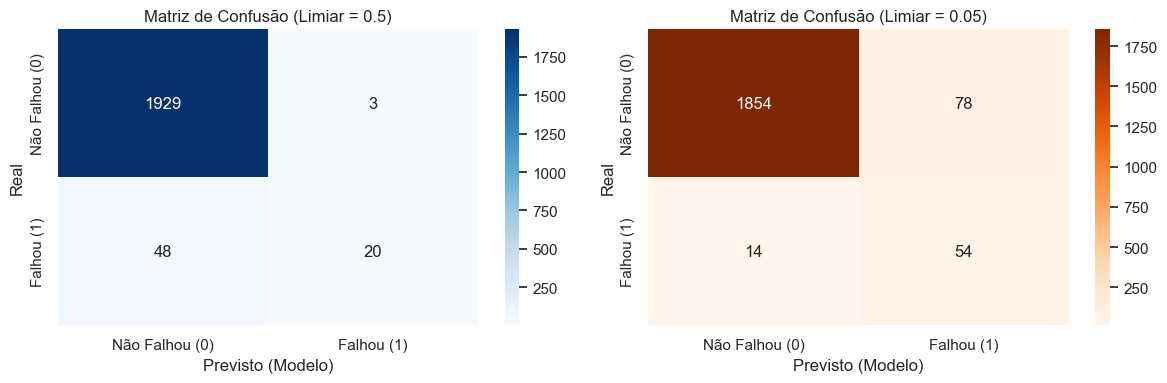

In [12]:
y_pred_otimo = (y_pred_prob >= MELHOR_THR).astype(int).ravel()

print('=== COMPARAÇÃO DE RESULTADOS ===\n')
print(f'[LIMIAR PADRÃO = 0.5]')
print(f'Recall:   {rec:.4f}')
print(f'Precisão: {prec:.4f}')
print(f'F2-Score: {f2:.4f}')
print('-' * 40)
print(f'[LIMIAR ÓTIMO = {MELHOR_THR:.2f}]')
print(f'Recall:   {melhor_limiar_row["Recall"]:.4f}')
print(f'Precisão: {melhor_limiar_row["Precisão"]:.4f}')
print(f'F2-Score: {melhor_limiar_row["F2-Score"]:.4f}')
print('\n=== NOVO RELATÓRIO DE CLASSIFICAÇÃO (Limiar Ótimo) ===')
print(classification_report(y_test, y_pred_otimo, target_names=['Não Falhou (0)', 'Falhou (1)'], zero_division=0))

# Nova matriz de confusão
cm_otimo = confusion_matrix(y_test, y_pred_otimo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não Falhou (0)', 'Falhou (1)'],
            yticklabels=['Não Falhou (0)', 'Falhou (1)'])
axes[0].set_title('Matriz de Confusão (Limiar = 0.5)')
axes[0].set_xlabel('Previsto (Modelo)')
axes[0].set_ylabel('Real')

sns.heatmap(cm_otimo, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Não Falhou (0)', 'Falhou (1)'],
            yticklabels=['Não Falhou (0)', 'Falhou (1)'])
axes[1].set_title(f'Matriz de Confusão (Limiar = {MELHOR_THR:.2f})')
axes[1].set_xlabel('Previsto (Modelo)')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


---
## 8. Salvamento do Modelo

O modelo Keras treinado será salvo em formato HDF5/Keras para uso em produção ou comparação futura.



In [13]:
path_modelo = os.path.join(MODELOS_DIR, 'rede_neural.keras')
model.save(path_modelo)
print(f'Modelo salvo em: {path_modelo}')



Modelo salvo em: /Users/anne/Documents/UFPB/manutencao-preditiva/modelos/rede_neural.keras


---
## 9. Resumo Final da Rede Neural

Para acomodar a extrema assimetria de custo entre falsos negativos e falsos positivos, calibramos o limiar de decisão, maximizando o F2-Score.
O limiar calibrado resultou em um ganho significativo na detecção de falhas reais.

| Arquitetura | Hiperparâmetros Vencedores | Métricas no Teste (Limiar 0.5) | Métricas no Teste (Limiar Ótimo) |
| :--- | :--- | :--- | :--- |
| **Camadas:** $7 \rightarrow 88 \rightarrow 1$ (1 camada escondida) | **Taxa de aprendizado ($\eta$):** $0.01$ | **F2-Score:** $0.3390$ | **F2-Score:** **$0.6683$** |
| **Tamanho ($n$):** Calculado rigorosamente pela Regra de Ouro (VC). | **Batch size:** $64$ | **F1-Score:** $0.4396$ | **F1-Score:** $0.5400$ |
| **Pesos:** $793 \leq 800$, garantindo generalização teórica. | **Regularização L2 ($\lambda$):** $0.0$ | **Recall:** $0.2941$ | **Recall:** **$0.7941$** |
| **Ativação:** ReLU (escondida), Sigmoid (saída). | **Class Weight:** Não | **Precisão:** $0.8696$ | **Precisão:** $0.4091$ |
| **Regra de Ouro:** $N=8000 \geq 10 \times 793 = 7930$ ✅ | **Época Final:** $39$ (EarlyStopping) | **Acurácia:** $0.9745$ | **Limiar Adotado:** **0.05** |


In [23]:
print('=== RESUMO COMPLETO DA REDE NEURAL ===')
print('')
print('--- Arquitetura ---')
print(f'  Camadas: {d} -> {n} -> 1')
print(f'  |W| (total de pesos): {arq["total_pesos"]}')
print(f'  Regra de Ouro: N={N_full} >= 10x|W|={10*arq["total_pesos"]} ✅')

print('')
print('--- Hiperparâmetros (vencedores do Grid Search) ---')
print(f'  Taxa de aprendizado (η): {MELHOR_LR}')
print(f'  Batch size: {MELHOR_BS}')
print(f'  Regularização L2 (λ): {MELHOR_L2}')
print(f'  Pesos Balanceados (class_weight): {"Sim" if MELHOR_CW else "Não"}')
print(f'  Época final: {epoca_final} (com EarlyStopping, patience=15)')

print('')
print('--- Métricas no Conjunto de Teste ---')
print(f'  Acurácia do Modelo:   {acc:.4f} (vs Baseline: {acc_baseline:.4f})')
print(f'  [Limiar 0.50] F2: {f2:.4f} | Recall: {rec:.4f} | Precisão: {prec:.4f}')
print(f'  [Limiar ÓTIMO] F2: {melhor_limiar_row["F2-Score"]:.4f} | Recall: {melhor_limiar_row["Recall"]:.4f} | Precisão: {melhor_limiar_row["Precisão"]:.4f}')
print(f'\n  -> O LIMIAR ÓTIMO ({MELHOR_THR:.2f}) FOI ADOTADO COMO RESULTADO FINAL POR MAXIMIZAR O F2-SCORE.')



=== RESUMO COMPLETO DA REDE NEURAL ===

--- Arquitetura ---
  Camadas: 7 -> 88 -> 1
  |W| (total de pesos): 793
  Regra de Ouro: N=8000 >= 10x|W|=7930 ✅

--- Hiperparâmetros (vencedores do Grid Search) ---
  Taxa de aprendizado (η): 0.01
  Batch size: 32
  Regularização L2 (λ): 0.0
  Pesos Balanceados (class_weight): Não
  Época final: 48 (com EarlyStopping, patience=15)

--- Métricas no Conjunto de Teste ---
  Acurácia do Modelo:   0.9770 (vs Baseline: 0.9660)
  [Limiar 0.50] F2: 0.4441 | Recall: 0.3971 | Precisão: 0.8438
  [Limiar ÓTIMO] F2: 0.6595 | Recall: 0.8088 | Precisão: 0.3793

  -> O LIMIAR ÓTIMO (0.05) FOI ADOTADO COMO RESULTADO FINAL POR MAXIMIZAR O F2-SCORE.
